# Version 1

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

num_pipe = make_column_transformer(
    (make_pipeline(
        SimpleImputer(strategy='median'), 
        StandardScaler()), 
    ['patient_age']),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

cat_pipe = make_column_transformer(
    (make_pipeline(
        SimpleImputer(strategy='most_frequent'), 
        OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)), 
    ['gender']),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

tabular_pipe = make_pipeline(num_pipe, cat_pipe)

In [ ]:
df = pd.read_pickle('../data/processed_data.pkl')
tabular_pipe.fit_transform(df)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
from torchvision import transforms

class OsteoDataset(Dataset):
    def __init__(self, image_dir, tabular_data, transform=None):
        # Construct list of image paths
        self.img_paths = list(image_dir + tabular_data.uid.astype(str) + '.png')  # Ensure the paths are strings
        self.tabular_data = tabular_data
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        try:
            # Get tabular data and label
            row = self.tabular_data.iloc[idx]
            inverted = (row['photometric'] == 'MONOCHROME1')
            tabular_features = torch.tensor([
                row['patient_age'],
                row['gender_MALE']
            ], dtype=torch.float32)

            label = row['target']

            # Load image
            image = Image.open(self.img_paths[idx]).convert('L')  # Convert any image to grayscale

            if inverted:
                image = transforms.functional.invert(image)

            if self.transform:
                image = self.transform(image)

            return image, tabular_features, label

        except Exception as e:
            print(f"Error loading item {idx}: {e}")
            print(f"File path: {self.img_paths[idx]}")
            raise

In [4]:
dataset = OsteoDataset(
    image_dir='../data/Images/png_files/',
    tabular_data=tabular_pipe.fit_transform(df),
    transform=None  # Add any transformations if needed
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
for i in range(100):
    image, tabular_features, label = dataset[i]
    plt.subplot(10, 10, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

# Version 2

## Explore Monai pipelines

In [610]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, 
    Resized, ToTensord, EnsureTyped, OrientationD, ScaleIntensityRangePercentilesd, CropForegroundd, NormalizeIntensityd
)
from monai.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import pydicom
from PIL import Image
import torch

import numpy as np, torch
from monai.transforms import MapTransform

Found 519 DICOM files


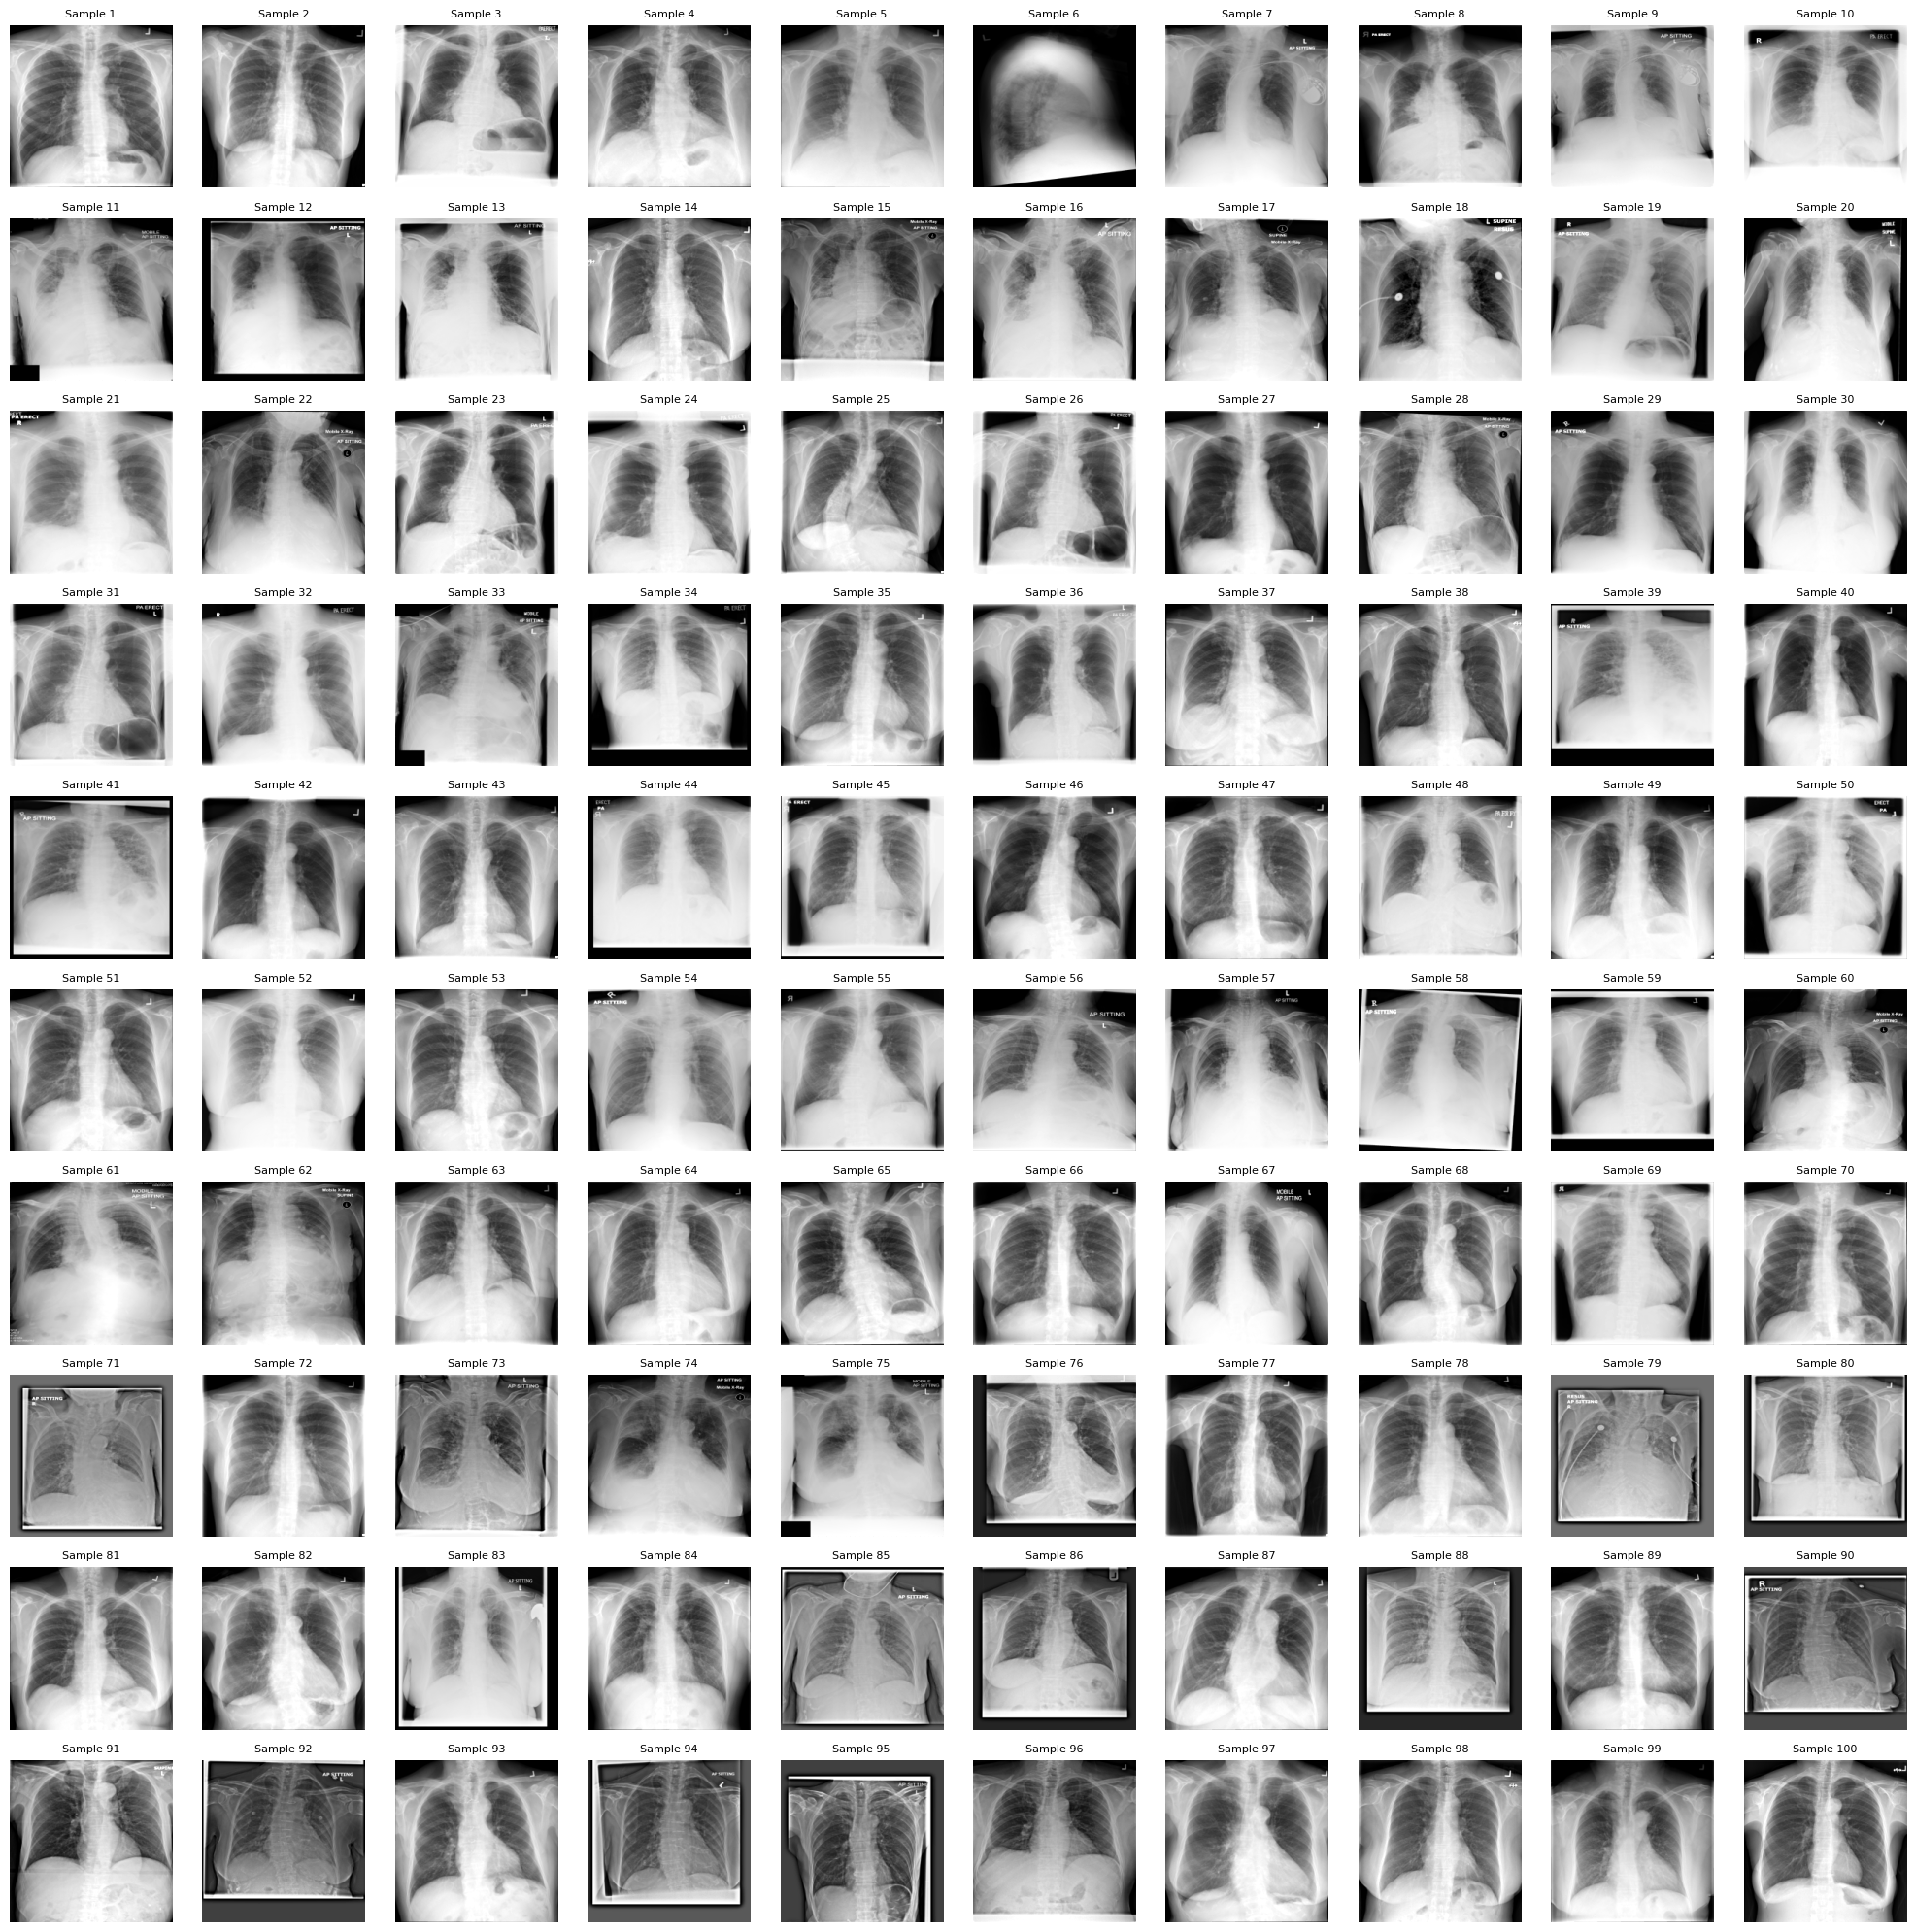

In [611]:
data_dir = '../data/Images/01_CXR1'

# Recursively find all DICOM files in the directory
def get_dicom_files(data_dir):
    dicom_files = []
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.dcm', '.dicom')):
                dicom_files.append(os.path.join(root, file))
    return dicom_files

# Get all DICOM files
dicom_files = get_dicom_files(data_dir)
print(f"Found {len(dicom_files)} DICOM files")

# Create data dictionary for MONAI
data_dicts = [{"image": file} for file in dicom_files]

class PhotometricInvertTransform(MapTransform):
    """
    Check DICOM photometric interpretation and invert if MONOCHROME1.
    MONOCHROME1 means pixel value 0 should be displayed as white.
    MONOCHROME2 means pixel value 0 should be displayed as black.
    """
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            # Get the original file path from meta data
            file_path = d[key + "_meta_dict"]["filename_or_obj"]
            
            # Read DICOM header to check photometric interpretation
            ds = pydicom.dcmread(file_path, stop_before_pixels=True)
            photometric = getattr(ds, 'PhotometricInterpretation', None)
            
            if photometric == 'MONOCHROME1':
                # Invert the image for MONOCHROME1
                img = d[key]
                if isinstance(img, torch.Tensor):
                    d[key] = torch.max(img) - img
                else:
                    d[key] = np.max(img) - img
        return d


# Define MONAI transforms with histogram equalization


monai_transforms = Compose([
    LoadImaged(keys=["image"], image_only=False, reader="PydicomReader"),
    EnsureChannelFirstd(keys=["image"]),
    PhotometricInvertTransform(keys=["image"]),  # Check and invert if MONOCHROME1
    EnsureTyped(keys=["image"], track_meta=True, dtype=torch.float32),
    CropForegroundd(keys=["image"], source_key="image"),  # Remove black borders
    Resized(keys=["image"], spatial_size=(224, 224), mode="area"),
    OrientationD(keys=["image"], axcodes="RA"),
    ScaleIntensityRangePercentilesd(
    keys=["image"], lower=1, upper=99, b_min=0.0, b_max=1.0, clip=True)
])


# Create MONAI dataset
monai_dataset = Dataset(data=data_dicts, transform=monai_transforms)

# Plot 10x10 grid of samples from the MONAI dataset
fig, axes = plt.subplots(10, 10, figsize=(20, 20))

for i in range(100):
    row = i // 10
    col = i % 10
    sample = monai_dataset[i]
    image = sample["image"]

    axes[row, col].imshow(image.squeeze(0), cmap='gray')
    axes[row, col].set_title(f'Sample {i+1}', fontsize=8)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [614]:
next(iter(monai_dataset))

{'image': metatensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0115, 0.0109, 0.0036],
          [0.0000, 0.0000, 0.0000,  ..., 0.0106, 0.0113, 0.0028],
          [0.0000, 0.0000, 0.0000,  ..., 0.0120, 0.0106, 0.0033],
          ...,
          [0.2517, 0.3475, 0.3791,  ..., 0.2172, 0.2365, 0.2321],
          [0.3447, 0.4438, 0.4702,  ..., 0.3002, 0.3087, 0.3039],
          [0.4888, 0.5927, 0.6199,  ..., 0.0271, 0.0277, 0.0275]]]),
 'image_meta_dict': {spatial_shape: (3000, 3000),
  space: RAS,
  original_affine: array([[0., 1., 0., 0.],
         [1., 0., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]]),
  affine: tensor([[0., 1., 0., 0.],
          [1., 0., 0., 0.],
          [0., 0., 1., 0.],
          [0., 0., 0., 1.]], dtype=torch.float64),
  original_channel_dim: nan,
  'spacing': array([1., 1.]),
  'filename_or_obj': '..\\data\\Images\\01_CXR1\\20130109_3f6a2cf08dbd6d8f37fa\\1.2.826.0.1.3680043.8.498.84193088049919716552213049919203208843\\CR1.2.826.0.1.3680043.8.498.863631

In [615]:
next(iter(monai_dataset))['image']

metatensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0115, 0.0109, 0.0036],
         [0.0000, 0.0000, 0.0000,  ..., 0.0106, 0.0113, 0.0028],
         [0.0000, 0.0000, 0.0000,  ..., 0.0120, 0.0106, 0.0033],
         ...,
         [0.2517, 0.3475, 0.3791,  ..., 0.2172, 0.2365, 0.2321],
         [0.3447, 0.4438, 0.4702,  ..., 0.3002, 0.3087, 0.3039],
         [0.4888, 0.5927, 0.6199,  ..., 0.0271, 0.0277, 0.0275]]])

In [13]:
import numpy as np, torch
from monai.transforms import MapTransform

class CLAHEd(MapTransform):
    """
    Apply CLAHE per-channel on (C,H,W) tensors.
    Expects float images in [0,1] (use ScaleIntensityd beforehand).
    Uses skimage if available (better for float), else OpenCV (quantizes to 8-bit).
    """
    def __init__(self, keys, clip_limit=0.01, tile_grid_size=(8, 8), nbins=512):
        super().__init__(keys)
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.nbins = nbins
        # backends
        try:
            from skimage.exposure import equalize_adapthist
            self._sk_clahe = equalize_adapthist
        except Exception:
            self._sk_clahe = None
        try:
            import cv2
            self._cv2 = cv2
        except Exception:
            self._cv2 = None

    def _clahe_skimage(self, x):
        # x: float ndarray in [0,1]
        return self._sk_clahe(x, clip_limit=self.clip_limit,
                              nbins=self.nbins, kernel_size=self.tile_grid_size).astype(np.float32)

    def _clahe_cv2(self, x):
        # x: float ndarray in [0,1] -> convert to 8-bit for OpenCV
        img8 = np.clip(x * 255.0, 0, 255).astype(np.uint8)
        clahe = self._cv2.createCLAHE(clipLimit=max(self.clip_limit * 100, 2.0),  # rough scaling
                                      tileGridSize=self.tile_grid_size)
        out8 = clahe.apply(img8)
        return (out8.astype(np.float32) / 255.0)

    def __call__(self, data):
        d = dict(data)
        for k in self.keys:
            img = d[k]
            # (C,H,W) expected; clamp to [0,1]
            if isinstance(img, torch.Tensor):
                arr = img.detach().cpu().numpy()
            else:
                arr = img
            arr = np.clip(arr, 0.0, 1.0)

            out = np.empty_like(arr, dtype=np.float32)
            for c in range(arr.shape[0]):
                if self._sk_clahe is not None:
                    out[c] = self._clahe_skimage(arr[c])
                elif self._cv2 is not None:
                    out[c] = self._clahe_cv2(arr[c])
                else:
                    raise ImportError("Install scikit-image or opencv-python to use CLAHEd.")

            d[k] = torch.from_numpy(out).to(img.dtype) if isinstance(img, torch.Tensor) else out.astype(img.dtype)
        return d


##  Transforms pipeline

In [619]:
# train
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, EnsureTyped, CropForegroundd,
    Resized, OrientationD, ScaleIntensityRangePercentilesd,
    RandFlipd, RandAffined, RandAdjustContrastd, RepeatChanneld, ToTensord
)

train_transforms = Compose([
    LoadImaged(keys=["image"], image_only=False, reader="PydicomReader", ensure_channel_first=True),
    # PhotometricInvertTransform(keys=["image"]), # not using since tabular data already have
    EnsureTyped(keys=["image"], track_meta=True, dtype=torch.float32),
    CropForegroundd(keys=["image"], source_key="image"),
    Resized(keys=["image"], spatial_size=(224, 224), mode="area"),
    OrientationD(keys=["image"], axcodes="RA"),
    ScaleIntensityRangePercentilesd(keys=["image"], lower=1, upper=99, b_min=0.0, b_max=1.0, clip=True),
    # RepeatChanneld(keys=["image"], repetitions=3),  # enable if model needs 3-ch
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandAffined(keys=["image"], prob=1.0, rotate_range=0.175, translate_range=(0.05, 0.05), scale_range=(0.1, 0.1), mode="bilinear"),
    RandAdjustContrastd(keys=["image"], prob=1.0, gamma=(0.9, 1.1)),
])

# validation/test (no augments; keep normalization identical)
val_transforms = Compose([
    LoadImaged(keys=["image"], image_only=False, reader="PydicomReader", ensure_channel_first=True),
    PhotometricInvertTransform(keys=["image"]),
    EnsureTyped(keys=["image"], track_meta=True, dtype=torch.float32),
    CropForegroundd(keys=["image"], source_key="image"),
    Resized(keys=["image"], spatial_size=(224, 224), mode="area"),
    OrientationD(keys=["image"], axcodes="RA"),
    ScaleIntensityRangePercentilesd(keys=["image"], lower=1, upper=99, b_min=0.0, b_max=1.0, clip=True),
])

## Checking which dicom are available based on processed train data - for testing below

In [51]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

num_pipe = make_column_transformer(
    (make_pipeline(
        SimpleImputer(strategy='median'), 
        StandardScaler()), 
    ['patient_age']),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

cat_pipe = make_column_transformer(
    (make_pipeline(
        SimpleImputer(strategy='most_frequent'), 
        OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)), 
    ['gender']),
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

tabular_pipe = make_pipeline(num_pipe, cat_pipe)

In [52]:
df = pd.read_pickle('../data/processed_train.pkl')
tabular_pipe.fit_transform(df)

,gender_MALE,patient_age,uid,photometric,target,strat_var
112308,0.0,0.132276,1.2.826.0.1.3680043.8.498.42390888814664320877...,MONOCHROME1,2,2_FEMALE_>65_Out-Patient (O)_1
68286,0.0,0.100855,1.2.826.0.1.3680043.8.498.11224741930040634984...,MONOCHROME2,2,2_FEMALE_>65_Out-Patient (O)_0
89933,0.0,1.491245,1.2.826.0.1.3680043.8.498.70812374633761067667...,MONOCHROME1,1,1_FEMALE_>65_A&E (E)_0
114037,0.0,1.436258,1.2.826.0.1.3680043.8.498.93689708484038728474...,MONOCHROME1,2,2_FEMALE_>65_A&E (E)_0
110843,1.0,0.949228,1.2.826.0.1.3680043.8.498.63369686721727622830...,MONOCHROME1,2,2_MALE_>65_In-Patient (I)_0
...,...,...,...,...,...,...
101103,0.0,-0.111239,1.2.826.0.1.3680043.8.498.25996872366956262713...,MONOCHROME1,2,2_FEMALE_>65_Out-Patient (O)_1
116067,0.0,0.705714,1.2.826.0.1.3680043.8.498.11426533492413871885...,MONOCHROME1,1,1_FEMALE_>65_In-Patient (I)_0
27972,0.0,1.357705,1.2.826.0.1.3680043.8.498.74457064876369253873...,MONOCHROME1,2,2_FEMALE_>65_A&E (E)_0
91562,0.0,-0.331188,1.2.826.0.1.3680043.8.498.56861955650177878768...,MONOCHROME2,2,2_FEMALE_>65_Out-Patient (O)_0


In [543]:
import os
import pandas as pd
import pydicom

def extract_uids_from_dicom_directory(directory_path):
    """Extract UIDs and other metadata from DICOM files in a directory"""
    metadata = []
    
    for root, dirs, files in os.walk(directory_path):
        for filename in files:
            if filename.endswith('.dcm'):
                try:
                    filepath = os.path.join(root, filename)
                    ds = pydicom.dcmread(filepath, stop_before_pixels=True)
                    # Extract multiple UID types and other metadata
                    file_metadata = {
                        'filename': filename,
                        'filepath': filepath,
                        'SOPInstanceUID': getattr(ds, 'SOPInstanceUID', None),
                        'StudyInstanceUID': getattr(ds, 'StudyInstanceUID', None),
                        'SeriesInstanceUID': getattr(ds, 'SeriesInstanceUID', None),
                        'AccessionNumber': getattr(ds, 'AccessionNumber', None),
                        'PatientID': getattr(ds, 'PatientID', None),
                        'SeriesDescription': getattr(ds, 'SeriesDescription', None),
                        'PhotometricInterpretation': getattr(ds, 'PhotometricInterpretation', None),
                        'AcquisitionDeviceProcessingDescription': getattr(ds, 'AcquisitionDeviceProcessingDescription', None)
                    }
                    metadata.append(file_metadata)
                        
                except Exception as e:
                    print(f"Error reading {filename}: {e}")
                    continue
    
    return metadata

# Extract metadata from the DICOM directory
dicom_dir = r'C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1'
extracted_metadata = extract_uids_from_dicom_directory(dicom_dir)

# Create dataframe with all metadata
dicom_df = pd.DataFrame(extracted_metadata)
print(f"Found {len(dicom_df)} DICOM files")

# Match with processed dataframe
df = pd.read_pickle('../data/processed_train.pkl')

# Create matching columns - check if UIDs from processed data exist in DICOM files
# Using StudyInstanceUID as the primary matching field
df['uid_match'] = df['uid'].isin(dicom_df['StudyInstanceUID']).astype(int)

# Also check SeriesInstanceUID match
df['series_uid_match'] = df['uid'].isin(dicom_df['SeriesInstanceUID']).astype(int)

# Also check SOPInstanceUID match
df['sop_uid_match'] = df['uid'].isin(dicom_df['SOPInstanceUID']).astype(int)

# Check how many matches we have
print(f"StudyInstanceUID matches: {df['uid_match'].sum()} out of {len(df)}")
print(f"SeriesInstanceUID matches: {df['series_uid_match'].sum()} out of {len(df)}")
print(f"SOPInstanceUID matches: {df['sop_uid_match'].sum()} out of {len(df)}")

# Display the results
print("\nMatching summary:")
print(f"Total processed records: {len(df)}")
print(f"Total DICOM files found: {len(dicom_df)}")
print(f"Records with StudyInstanceUID match: {df['uid_match'].sum()}")
print(f"Records with SeriesInstanceUID match: {df['series_uid_match'].sum()}")
print(f"Records with SOPInstanceUID match: {df['sop_uid_match'].sum()}")

dicom_df


c:\Users\sufya\Documents\SGH\osteo\env\lib\site-packages\pydicom\valuerep.py:443: UserWarning: The value length (20) exceeds the maximum length of 16 allowed for VR SH.
  warnings.warn(msg)


Found 519 DICOM files
StudyInstanceUID matches: 0 out of 16835
SeriesInstanceUID matches: 0 out of 16835
SOPInstanceUID matches: 231 out of 16835

Matching summary:
Total processed records: 16835
Total DICOM files found: 519
Records with StudyInstanceUID match: 0
Records with SeriesInstanceUID match: 0
Records with SOPInstanceUID match: 231


,filename,filepath,SOPInstanceUID,StudyInstanceUID,SeriesInstanceUID,AccessionNumber,PatientID,SeriesDescription,PhotometricInterpretation,AcquisitionDeviceProcessingDescription
0,CR1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130109_3f6a2cf08dbd6d8f37fa\1.2.826.0.1.3680043.8.498.84193088049919716552213049919203208843\CR1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359.dcm,1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359,1.2.826.0.1.3680043.8.498.68321322479145275469601550878715969141,1.2.826.0.1.3680043.8.498.84193088049919716552213049919203208843,3f6a2cf08dbd6d8f37fa,e999c4e22b822d2ef12f,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
1,CR1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130129_29bf51acd8e0a9f3782c\1.2.826.0.1.3680043.8.498.39382668402516005637271172816319147461\CR1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356.dcm,1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356,1.2.826.0.1.3680043.8.498.29828218813151014059943434565770681310,1.2.826.0.1.3680043.8.498.39382668402516005637271172816319147461,29bf51acd8e0a9f3782c,d6b03209e8cb98b273f2,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
2,CR1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130401_e3b9229ed925b0c61b48\1.2.826.0.1.3680043.8.498.12502468425464122253466913093118182385\CR1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280.dcm,1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280,1.2.826.0.1.3680043.8.498.52625622577684897093989186640479175273,1.2.826.0.1.3680043.8.498.12502468425464122253466913093118182385,e3b9229ed925b0c61b48,b968fa7c666b62ad6ac2,Chest PA Erect,MONOCHROME1,Chest PA Erect
3,CR1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130404_8c4b698ba79c3909a3d3\1.2.826.0.1.3680043.8.498.94836153482937676002294349269919013277\CR1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718.dcm,1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718,1.2.826.0.1.3680043.8.498.80042259281382900246465535574032702184,1.2.826.0.1.3680043.8.498.94836153482937676002294349269919013277,8c4b698ba79c3909a3d3,f85fe7db95959c88be91,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
4,CR1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130514_1d8ea4b76d13e2b87d70\1.2.826.0.1.3680043.8.498.12904858055955505401226819607473518323\CR1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252.dcm,1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252,1.2.826.0.1.3680043.8.498.10520134754835298105277744556008718795,1.2.826.0.1.3680043.8.498.12904858055955505401226819607473518323,1d8ea4b76d13e2b87d70,f85fe7db95959c88be91,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
...,...,...,...,...,...,...,...,...,...,...
514,CR1.2.826.0.1.3680043.8.498.79501540157646367374258959406883111793.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20231208_e8c0627a506e92a34506\1.2.826.0.1.3680043.8.498.91261214057334059490255273762006441088\CR1.2.826.0.1.3680043.8.498.79501540157646367374258959406883111793.dcm,1.2.826.0.1.3680043.8.498.79501540157646367374258959406883111793,1.2.826.0.1.3680043.8.498.48297934720611703729637027466115880662,1.2.826.0.1.3680043.8.498.91261214057334059490255273762006441088,e8c0627a506e92a34506,c0c47169befed19dd33c,Chest PA grid (ave),MONOCHROME1,Chest PA grid (ave)
515,DX1.2.826.0.1.3680043.8.498.13798858138409489683309509526766199647.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20231216_8ba6aa3ad911671f1b77\1.2.826.0.1.3680

In [544]:
df = df[df['sop_uid_match'] ==1].iloc[:,:-3]

In [545]:
df

,uid,patient_age,gender,photometric,target,strat_var
796,1.2.826.0.1.3680043.8.498.64474354370693920915855805102102068050,85.8,FEMALE,MONOCHROME1,1,1_FEMALE_>65_A&E (E)_0
925,1.2.826.0.1.3680043.8.498.11407485139131011444582343146029466732,62.0,FEMALE,MONOCHROME1,0,0_FEMALE_50-65_Out-Patient (O)_1
1372,1.2.826.0.1.3680043.8.498.15937119569019314556645654647318530544,67.7,FEMALE,MONOCHROME2,2,2_FEMALE_>65_Out-Patient (O)_0
167,1.2.826.0.1.3680043.8.498.80789168045765691484126853291019034625,83.1,FEMALE,MONOCHROME2,1,1_FEMALE_>65_A&E (E)_0
40,1.2.826.0.1.3680043.8.498.11385715588573369792967691135711238258,78.7,FEMALE,MONOCHROME2,2,2_FEMALE_>65_Out-Patient (O)_0
...,...,...,...,...,...,...
699,1.2.826.0.1.3680043.8.498.55826346692337558066582613758237778356,51.4,FEMALE,MONOCHROME1,2,2_FEMALE_50-65_In-Patient (I)_0
1010,1.2.826.0.1.3680043.8.498.83348821519340867355239376408211058354,77.1,MALE,MONOCHROME2,2,2_MALE_>65_In-Patient (I)_0
1439,1.2.826.0.1.3680043.8.498.52056029646720267668620691455101972188,87.5,FEMALE,MONOCHROME2,2,2_FEMALE_>65_Out-Patient (O)_0
884,1.2.826.0.1.3680043.8.498.83829619185064001518262324869763867526,75.9,FEMALE,MONOCHROME2,2,2_FEMALE_>65_Out-Patient (O)_0


In [64]:
# Display full column content without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 10)

dicom_df

,filename,filepath,SOPInstanceUID,StudyInstanceUID,SeriesInstanceUID,AccessionNumber,PatientID,SeriesDescription,PhotometricInterpretation,AcquisitionDeviceProcessingDescription
0,CR1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130109_3f6a2cf08dbd6d8f37fa\1.2.826.0.1.3680043.8.498.84193088049919716552213049919203208843\CR1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359.dcm,1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359,1.2.826.0.1.3680043.8.498.68321322479145275469601550878715969141,1.2.826.0.1.3680043.8.498.84193088049919716552213049919203208843,3f6a2cf08dbd6d8f37fa,e999c4e22b822d2ef12f,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
1,CR1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130129_29bf51acd8e0a9f3782c\1.2.826.0.1.3680043.8.498.39382668402516005637271172816319147461\CR1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356.dcm,1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356,1.2.826.0.1.3680043.8.498.29828218813151014059943434565770681310,1.2.826.0.1.3680043.8.498.39382668402516005637271172816319147461,29bf51acd8e0a9f3782c,d6b03209e8cb98b273f2,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
2,CR1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130401_e3b9229ed925b0c61b48\1.2.826.0.1.3680043.8.498.12502468425464122253466913093118182385\CR1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280.dcm,1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280,1.2.826.0.1.3680043.8.498.52625622577684897093989186640479175273,1.2.826.0.1.3680043.8.498.12502468425464122253466913093118182385,e3b9229ed925b0c61b48,b968fa7c666b62ad6ac2,Chest PA Erect,MONOCHROME1,Chest PA Erect
3,CR1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130404_8c4b698ba79c3909a3d3\1.2.826.0.1.3680043.8.498.94836153482937676002294349269919013277\CR1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718.dcm,1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718,1.2.826.0.1.3680043.8.498.80042259281382900246465535574032702184,1.2.826.0.1.3680043.8.498.94836153482937676002294349269919013277,8c4b698ba79c3909a3d3,f85fe7db95959c88be91,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
4,CR1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20130514_1d8ea4b76d13e2b87d70\1.2.826.0.1.3680043.8.498.12904858055955505401226819607473518323\CR1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252.dcm,1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252,1.2.826.0.1.3680043.8.498.10520134754835298105277744556008718795,1.2.826.0.1.3680043.8.498.12904858055955505401226819607473518323,1d8ea4b76d13e2b87d70,f85fe7db95959c88be91,PA,MONOCHROME2,UNIQUE: S:200 L:4.0 FC d:1.8 g:0.6 sb:2 eq:-0.4 nr:0 dc:3 bal...
...,...,...,...,...,...,...,...,...,...,...
514,CR1.2.826.0.1.3680043.8.498.79501540157646367374258959406883111793.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20231208_e8c0627a506e92a34506\1.2.826.0.1.3680043.8.498.91261214057334059490255273762006441088\CR1.2.826.0.1.3680043.8.498.79501540157646367374258959406883111793.dcm,1.2.826.0.1.3680043.8.498.79501540157646367374258959406883111793,1.2.826.0.1.3680043.8.498.48297934720611703729637027466115880662,1.2.826.0.1.3680043.8.498.91261214057334059490255273762006441088,e8c0627a506e92a34506,c0c47169befed19dd33c,Chest PA grid (ave),MONOCHROME1,Chest PA grid (ave)
515,DX1.2.826.0.1.3680043.8.498.13798858138409489683309509526766199647.dcm,C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1\20231216_8ba6aa3ad911671f1b77\1.2.826.0.1.3680

In [66]:
import os
import shutil
from pathlib import Path

# Create the destination directory
dest_dir = Path(r'C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1_dicom_only')
dest_dir.mkdir(exist_ok=True)

# Process each file in the dicom_df
for idx, row in dicom_df.iterrows():
    source_filepath = row['filepath']
    sop_instance_uid = row['SOPInstanceUID']
    
    # Construct source file path
    source_file = Path(source_filepath)
    
    # Create new filename based on SOPInstanceUID
    new_filename = f"{sop_instance_uid}.dcm"
    dest_file = dest_dir / new_filename
    
    try:
        if source_file.exists():
            # Copy the file with new name
            shutil.copy2(source_file, dest_file)
            print(f"Copied: {source_file.name} -> {new_filename}")
        else:
            print(f"Warning: Source file not found: {source_file}")
    except Exception as e:
        print(f"Error copying {source_file.name}: {e}")

print(f"\nCompleted! Processed {len(dicom_df)} files.")
print(f"Files saved to: {dest_dir}")

Copied: CR1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359.dcm -> 1.2.826.0.1.3680043.8.498.86363197330862456493194645256455793359.dcm
Copied: CR1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356.dcm -> 1.2.826.0.1.3680043.8.498.19339028903568078559543791534408423356.dcm
Copied: CR1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280.dcm -> 1.2.826.0.1.3680043.8.498.11969623532651381071441383983093497280.dcm
Copied: CR1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718.dcm -> 1.2.826.0.1.3680043.8.498.39764625527590323454964484302790287718.dcm
Copied: CR1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252.dcm -> 1.2.826.0.1.3680043.8.498.53264644273061646388080609026746409252.dcm
Copied: CR1.2.826.0.1.3680043.8.498.71513933053890704790605183461581701756.dcm -> 1.2.826.0.1.3680043.8.498.71513933053890704790605183461581701756.dcm
Copied: CR1.2.826.0.1.3680043.8.498.13060656635571397077339728108421102583.dcm -> 1.2.826.0.1.

In [283]:
import os, shutil, pandas as pd, pydicom
from pathlib import Path

ROOT = r"C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1"
DEST = r"C:\Users\sufya\Documents\SGH\osteo\data\Images\01_CXR1_dicom_only"

# your tabular file with a column 'SOPInstanceUID'
df = dicom_df.copy()  # ensure dtype=str
df['SOPInstanceUID'] = df['SOPInstanceUID'].astype(str).str.strip()

# Image storage SOP Class UIDs to keep (CR/DX; extend if needed)
IMAGE_SOPCLASS = {
    "1.2.840.10008.5.1.4.1.1.1",      # CR Image Storage
    "1.2.840.10008.5.1.4.1.1.1.1",    # Digital X-Ray Image Storage - For Presentation
    "1.2.840.10008.5.1.4.1.1.1.2",    # Digital X-Ray Image Storage - For Processing
}

def scan_dicom(root):
    rows = []
    for dirpath, _, files in os.walk(root):
        for fn in files:
            fp = os.path.join(dirpath, fn)
            try:
                ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
            except Exception:
                continue
            sop = getattr(ds, "SOPInstanceUID", None)
            series = getattr(ds, "SeriesInstanceUID", None)
            study = getattr(ds, "StudyInstanceUID", None)
            sopclass = str(getattr(ds, "SOPClassUID", "")) if hasattr(ds, "SOPClassUID") else ""
            modality = getattr(ds, "Modality", "")
            nframes = int(getattr(ds, "NumberOfFrames", 1) or 1)
            instnum = getattr(ds, "InstanceNumber", None)
            rows.append({
                "path": fp,
                "size": os.path.getsize(fp),
                "SOPInstanceUID": str(sop) if sop else None,
                "SOPClassUID": sopclass,
                "Modality": modality,
                "StudyInstanceUID": str(study) if study else None,
                "SeriesInstanceUID": str(series) if series else None,
                "NumberOfFrames": nframes,
                "InstanceNumber": instnum
            })
    return pd.DataFrame(rows)

idx = scan_dicom(ROOT)

# keep only real X-ray image objects
idx_img = idx[idx["SOPClassUID"].isin(IMAGE_SOPCLASS)].copy()

# diagnose duplicates (should be rare)
dups = idx_img[idx_img.duplicated("SOPInstanceUID", keep=False)].sort_values("SOPInstanceUID")

# resolve duplicates by taking the largest file (or choose rule you prefer)
idx_img.sort_values(["SOPInstanceUID","size"], ascending=[True, False], inplace=True)
idx_unique = idx_img.drop_duplicates("SOPInstanceUID", keep="first")

# join to your tabular list of SOPs
matches = df.merge(idx_unique[["SOPInstanceUID","path","Modality","NumberOfFrames"]], on="SOPInstanceUID", how="left")

# report problems
missing_in_fs = df[~df["SOPInstanceUID"].isin(idx_unique["SOPInstanceUID"])]
extra_in_fs = idx_unique[~idx_unique["SOPInstanceUID"].isin(df["SOPInstanceUID"])]

# copy matched files
Path(DEST).mkdir(parents=True, exist_ok=True)
for r in matches.dropna(subset=["path"]).itertuples():
    shutil.copy2(r.path, os.path.join(DEST, f"{r.SOPInstanceUID}.dcm"))

In [657]:
from torch.utils.data import Dataset, DataLoader
import torch

class OsteoDataset(Dataset):
    def __init__(self, image_dir, tabular_data, transform=None):
        # Construct list of image paths as dict for MONAI transforms
        self.image_paths = [os.path.join(str(image_dir), str(uid) + '.dcm') for uid in tabular_data.uid]
        self.tabular_data = tabular_data
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            # Get tabular data and label
            row = self.tabular_data.iloc[idx]
            tabular_features = torch.tensor([
                row['patient_age'],
                row['gender_MALE']
            ], dtype=torch.float32)

            label = row['target']

            # Create data dict for MONAI transforms
            data_dict = {
                "image": self.image_paths[idx],
                # "photometric": row['photometric']
            }

            if self.transform:
                print(data_dict)
                data_dict['image'] = self.transform(data_dict)['image']

            return data_dict["image"], tabular_features, label

        except Exception as e:
            print(f"Error loading item {idx}: {e}")
            print(f"File path: {self.image_paths[idx]}")
            raise

tabular_data = tabular_pipe.fit_transform(df)
        
train_dataset = OsteoDataset(image_dir = '../data/Images/01_CXR1_dicom_only', tabular_data = tabular_data, transform = train_transforms)

img, tabular_features, label = next(iter(train_dataset))

img

{'image': '../data/Images/01_CXR1_dicom_only\\1.2.826.0.1.3680043.8.498.64474354370693920915855805102102068050.dcm'}


metatensor([[[0.9676, 0.9689, 0.9635,  ..., 0.9807, 0.9855, 0.9985],
         [0.9603, 0.9661, 0.9662,  ..., 0.9807, 0.9860, 0.9986],
         [0.9447, 0.9529, 0.9547,  ..., 0.9806, 0.9864, 0.9986],
         ...,
         [0.8913, 0.8917, 0.8920,  ..., 0.2719, 0.2536, 0.2366],
         [0.8839, 0.8839, 0.8839,  ..., 0.9908, 0.9965, 0.9993],
         [0.8893, 0.8890, 0.8886,  ..., 0.9842, 0.9874, 0.9898]]])